In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Load featured data
train = pd.read_csv('../data/processed/train_featured.csv')

# Use only sensor columns (original 14 sensors)
sensor_cols = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 
               'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 
               'sensor15', 'sensor17', 'sensor20', 'sensor21']

print("Data loaded successfully!")
print("Shape:", train.shape)
train[sensor_cols].describe().round(2)

Data loaded successfully!
Shape: (20631, 73)


,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
count,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00
mean,642.68,1590.52,1408.93,553.37,2388.10,9065.24,47.54,521.41,2388.10,8143.75,8.44,393.21,38.82,23.29
std,0.50,6.13,9.00,0.89,0.07,22.08,0.27,0.74,0.07,19.08,0.04,1.55,0.18,0.11
min,641.21,1571.04,1382.25,549.85,2387.90,9021.73,46.85,518.69,2387.88,8099.94,8.32,388.00,38.14,22.89
25%,642.33,1586.26,1402.36,552.81,2388.05,9053.10,47.35,520.96,2388.04,8133.24,8.41,392.00,38.70,23.22
50%,642.64,1590.10,1408.04,553.44,2388.09,9060.66,47.51,521.48,2388.09,8140.54,8.44,393.00,38.83,23.30
75%,643.00,1594.38,1414.55,554.01,2388.14,9069.42,47.70,521.95,2388.14,8148.31,8.47,394.00,38.95,23.37
max,644.53,1616.91,1441.49,556.06,2388.56,9244.59,48.53,523.38,2388.56,8293.72,8.58,400.00,39.43,23.62


In [2]:
# Scale sensor data
scaler = MinMaxScaler()
X_sensors = scaler.fit_transform(train[sensor_cols])

# Train Isolation Forest
# contamination=0.05 means we expect ~5% of readings to be anomalies
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_sensors)

# Predict anomalies
# Output: 1 = normal, -1 = anomaly
predictions = iso_forest.predict(X_sensors)
anomaly_scores = iso_forest.decision_function(X_sensors)

# Add results to dataframe
train['anomaly'] = predictions
train['anomaly_score'] = anomaly_scores
train['is_anomaly'] = (predictions == -1).astype(int)

# Summary
total = len(train)
anomalies = train['is_anomaly'].sum()
print(f"Total readings    : {total}")
print(f"Anomalies detected: {anomalies}")
print(f"Anomaly rate      : {anomalies/total*100:.2f}%")
print(f"\nAnomaly breakdown:")
print(train['is_anomaly'].value_counts())

Total readings    : 20631
Anomalies detected: 1032
Anomaly rate      : 5.00%

Anomaly breakdown:
is_anomaly
0    19599
1     1032
Name: count, dtype: int64


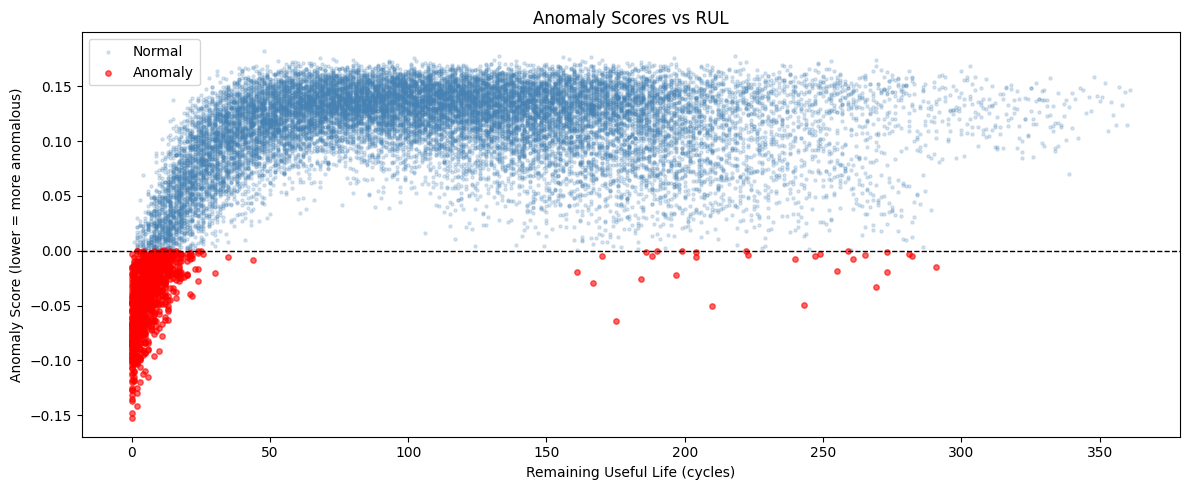

In [4]:
# Plot 1 — Anomalies vs RUL
plt.figure(figsize=(12, 5))
normal = train[train['is_anomaly'] == 0]
anomalies = train[train['is_anomaly'] == 1]

plt.scatter(normal['RUL'], normal['anomaly_score'], 
            alpha=0.2, s=5, color='steelblue', label='Normal')
plt.scatter(anomalies['RUL'], anomalies['anomaly_score'], 
            alpha=0.6, s=15, color='red', label='Anomaly')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Anomaly Score (lower = more anomalous)')
plt.title('Anomaly Scores vs RUL')
plt.legend()
plt.tight_layout()
plt.show()

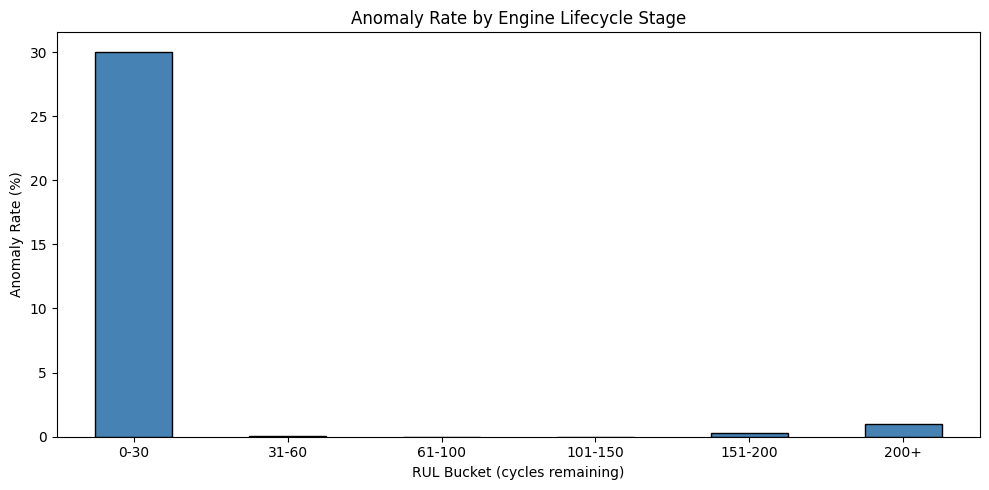

Anomaly rate by lifecycle stage:
rul_bucket
0-30       30.03
31-60       0.07
61-100      0.00
101-150     0.00
151-200     0.27
200+        0.97
Name: is_anomaly, dtype: float64


In [5]:
# Plot 2 — Anomaly rate per engine lifecycle stage
train['rul_bucket'] = pd.cut(train['RUL'], 
                              bins=[0, 30, 60, 100, 150, 200, 400],
                              labels=['0-30', '31-60', '61-100', 
                                      '101-150', '151-200', '200+'])

anomaly_by_stage = train.groupby('rul_bucket', observed=True)['is_anomaly'].mean() * 100

plt.figure(figsize=(10, 5))
anomaly_by_stage.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Anomaly Rate by Engine Lifecycle Stage')
plt.xlabel('RUL Bucket (cycles remaining)')
plt.ylabel('Anomaly Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Anomaly rate by lifecycle stage:")
print(anomaly_by_stage.round(2))

In [6]:
# Save anomaly results
train.to_csv('../data/processed/train_with_anomalies.csv', index=False)
print("Anomaly results saved!")

print("\n" + "="*40)
print("ANOMALY DETECTION SUMMARY")
print("="*40)
print(f"Model          : Isolation Forest")
print(f"Estimators     : 100")
print(f"Contamination  : 5%")
print(f"Total readings : 20,631")
print(f"Anomalies found: 1,032 (5%)")
print(f"Key finding    : 30% anomaly rate")
print(f"               when RUL < 30 cycles")
print(f"               vs <1% when healthy")
print("="*40)

Anomaly results saved!

ANOMALY DETECTION SUMMARY
Model          : Isolation Forest
Estimators     : 100
Contamination  : 5%
Total readings : 20,631
Anomalies found: 1,032 (5%)
Key finding    : 30% anomaly rate
               when RUL < 30 cycles
               vs <1% when healthy
